Final coefficients: a: 0.0013056202768007576, b: 8.590785413373037, c_t: 0.03509603535750335
Thrust Fit - MSE in Fit Range: 0.0315


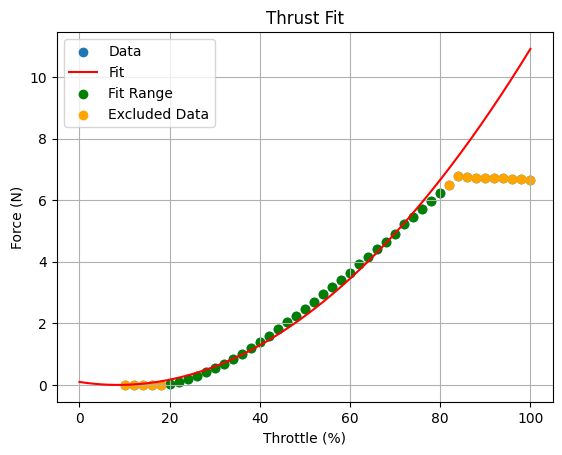

Torque Fit - MSE in Fit Range: 0.0001


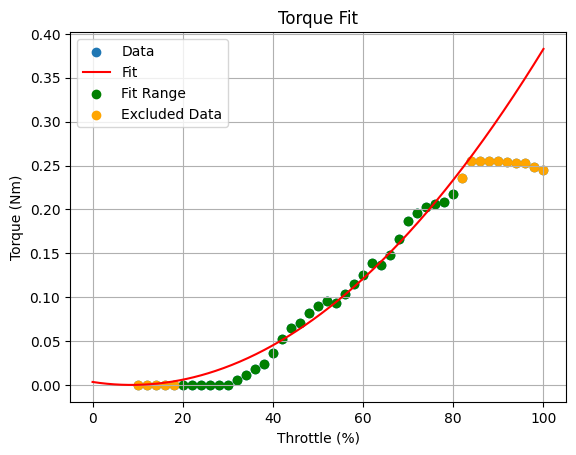

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

ARM_LENGTH = 0.2  # meters

ITERATIONS = 20

FIT_SPACE = (20, 80)


throttles = np.arange(10, 101, 2)
weights_thrust = np.array([
    0.00, 0.00, 0.00, 0.00, 0.00, 4.00, 11.00, 19.00, 30.00, 42.00,
    55.00, 70.30, 86.00, 102.70, 121.90, 142.90, 162.90, 184.60, 208.20,
    229.40, 252.70, 274.30, 300.10, 323.30, 347.50, 371.70, 398.60,
    423.20, 450.30, 474.20, 501.10, 531.80, 555.10, 582.40, 608.20,
    635.10, 663.10, 690.40, 686.80, 685.20, 684.90, 685.50, 683.20,
    680.50, 681.40, 679.20
])

weights_torque = np.array([ 
    0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 
    0.00, 3.00, 6.00, 9.00, 12.00, 18.80, 26.80, 32.90, 36.00, 41.80, 
    46.10, 49.00, 47.50, 52.90, 58.60, 64.10, 70.60, 69.70, 75.30, 84.60, 
    95.10, 100.00, 103.10, 105.00, 106.00, 110.90, 120.10, 130.10, 130.00, 130.00, 
    129.80, 129.50, 129.00, 128.90, 126.70, 125.10 
])


def fun(a, b, c, throttle):
    return c * a * (throttle - b) ** 2

def plot_fit(x, y, fit_mask, a, b, c, title, ylabel):
    y_pred_points = fun(a, b, c, x[fit_mask])
    print(f"{title} - MSE in Fit Range: {np.mean((y[fit_mask] - y_pred_points) ** 2):.4f}")

    plt.scatter(x, y, label='Data')
    x_fit = np.linspace(0, 100, 500)
    y_fit = fun(a, b, c, x_fit)
    plt.plot(x_fit, y_fit, color='red', label='Fit')
    plt.scatter(x[fit_mask], y[fit_mask], color='green', label='Fit Range')
    plt.scatter(x[~fit_mask], y[~fit_mask], color='orange', label='Excluded Data')
    plt.title(title)
    plt.xlabel('Throttle (%)')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid()
    plt.show()


forces = weights_thrust / 1000 * 9.81
torques = weights_torque / 1000 * 9.81 * ARM_LENGTH

fit_mask = (throttles >= FIT_SPACE[0]) & (throttles <= FIT_SPACE[1])

def loss(params):
    a, b, c_t = params

    forces_pred = fun(a, b, 1, throttles[fit_mask])
    torques_pred = fun(a, b, c_t, throttles[fit_mask])

    loss_forces = np.sum((forces[fit_mask] - forces_pred) ** 2) / np.sum(forces[fit_mask]) ** 2
    loss_torques = np.sum((torques[fit_mask] - torques_pred) ** 2) / np.sum(torques[fit_mask]) ** 2

    return loss_forces + loss_torques

initial_params = [0, 0, 0]
result = minimize(loss, initial_params)
a, b, c_t = result.x

print(f"Final coefficients: a: {a}, b: {b}, c_t: {c_t}")
plot_fit(throttles, forces, fit_mask, a, b, 1, 'Thrust Fit', 'Force (N)')
plot_fit(throttles, torques, fit_mask, a, b, c_t, 'Torque Fit', 'Torque (Nm)')